# Non-Buildings And Pipeline Drop-Off


## What this notebook shows

This notebook looks at cases where the reference footprint may not correspond to a visible
building and where the pipeline does not produce downstream geometry.


## Main reading

Use careful wording in the thesis. `house_present = false` should not automatically be
called a deleted building. It means no visible building was found in the patch by MLQA.
Possible explanations include non-building reference data, temporal mismatch, imagery
problems, occlusion, or misregistration.


## Recommended thesis framing

This section supports the argument that automated footprint correction is a geospatial
data-quality problem, not only an AI model-performance problem.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image


def find_repo_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "evaluation" / "statistics").exists():
            return p
    raise RuntimeError("Could not find repository root")


REPO_ROOT = find_repo_root()
STAT_DIR = REPO_ROOT / "evaluation" / "statistics"
TABLE_DIR = STAT_DIR / "tables"
FIG_DIR = STAT_DIR / "figures"


def show_table(name, n=None):
    df = pd.read_csv(TABLE_DIR / f"{name}.csv")
    display(df.head(n) if n else df)
    return df


def show_figure(name, width=850):
    display(Image(filename=str(FIG_DIR / f"{name}.png"), width=width))


,country,total_buildings,mlqa_analyzed,no_visible_house_mlqa,partial_house_mlqa,full_house_mlqa,with_sam,with_post,manually_evaluated,post_rate_of_sam_pct,manual_eval_rate_of_post_pct
0,Liberia,619,616,111,324,181,483,399,380,82.6,95.2
1,Mexico,1382,500,167,224,109,331,291,261,87.9,89.7
2,Mozambique,2826,600,424,122,54,176,169,167,96.0,98.8
3,Nepal,1181,626,359,198,69,263,235,192,89.4,81.7
4,Niger,991,500,222,103,175,265,258,256,97.4,99.2


,country,total_buildings,no_sam_detection,no_post_output,sam_but_no_post,with_post
0,Liberia,619,136,220,84,399
1,Mexico,1382,1051,1091,40,291
2,Mozambique,2826,2650,2657,7,169
3,Nepal,1181,918,946,28,235
4,Niger,991,726,733,7,258


,mlqa_error_type,count
0,MISALIGNED,1909
1,SHAPE_MISMATCH,1525
2,EXTRA_PARTS,1392
3,ORIENTATION_MISMATCH,547
4,MISSING_PARTS,55


,source,category,count,share_of_cases_pct,share_of_all_labels_pct
0,MLQA normalized errors,SHIFTED,1226,97.6,37.0
1,Manual original errors,SHIFTED,971,77.3,55.7
2,MLQA normalized errors,SHAPE_MISMATCH,1141,90.8,34.5
3,Manual original errors,SHAPE_MISMATCH,474,37.7,27.2
4,MLQA normalized errors,OVERSIMPLIFIED,0,0.0,0.0
5,Manual original errors,OVERSIMPLIFIED,171,13.6,9.8
6,MLQA normalized errors,MISSING_PARTS,32,2.5,1.0
7,Manual original errors,MISSING_PARTS,95,7.6,5.5
8,MLQA normalized errors,EXTRA_PARTS,912,72.6,27.5
9,Manual original errors,EXTRA_PARTS,31,2.5,1.8


,category,paired_cases,manual_count,mlqa_count,true_positive,false_positive,false_negative,true_negative,precision,recall,f1,accuracy,mlqa_minus_manual_count,mlqa_manual_count_ratio
0,SHIFTED,1256,971,1226,951,275,20,10,0.776,0.979,0.866,0.765,255,1.26
1,SHAPE_MISMATCH,1256,474,1141,426,715,48,67,0.373,0.899,0.528,0.393,667,2.41
2,OVERSIMPLIFIED,1256,171,0,0,0,171,1085,NaN,0.000,NaN,0.864,-171,0.00
3,MISSING_PARTS,1256,95,32,3,29,92,1132,0.094,0.032,0.047,0.904,-63,0.34
4,EXTRA_PARTS,1256,31,912,21,891,10,334,0.023,0.677,0.045,0.283,881,29.42


,paired_cases,exact_set_match_count,exact_set_match_pct,mean_jaccard_similarity,median_jaccard_similarity,mean_manual_labels_per_case,mean_mlqa_labels_per_case
0,1256,53,4.2,0.408,0.333,1.39,2.64


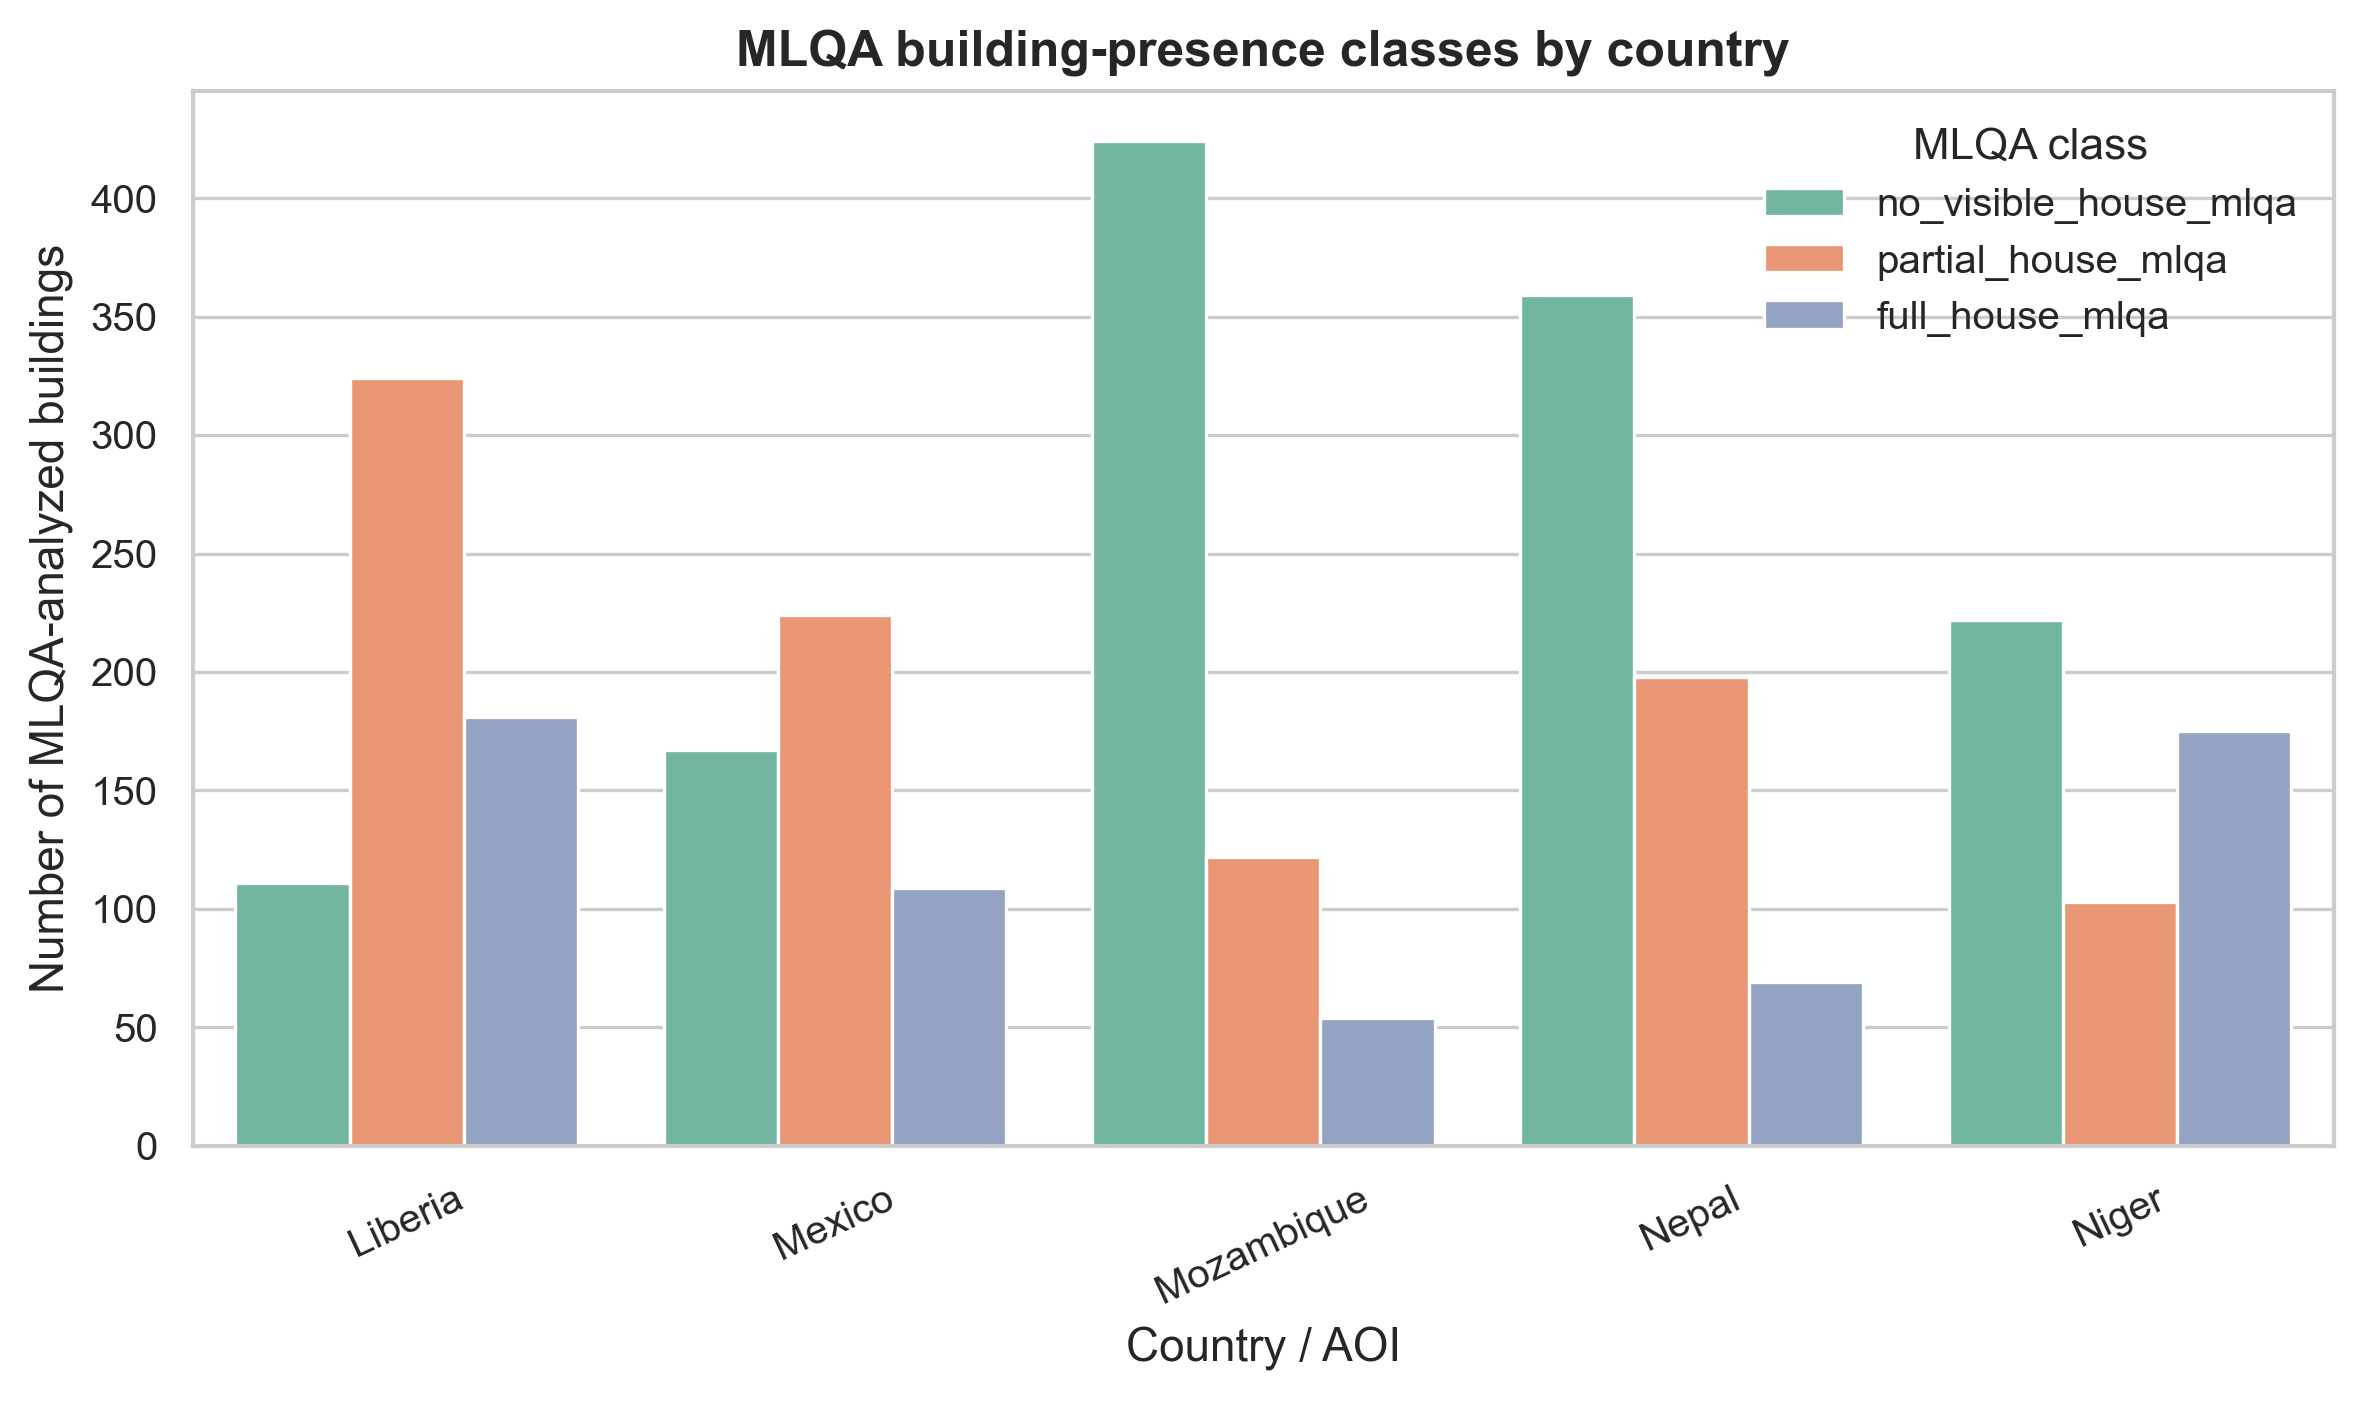

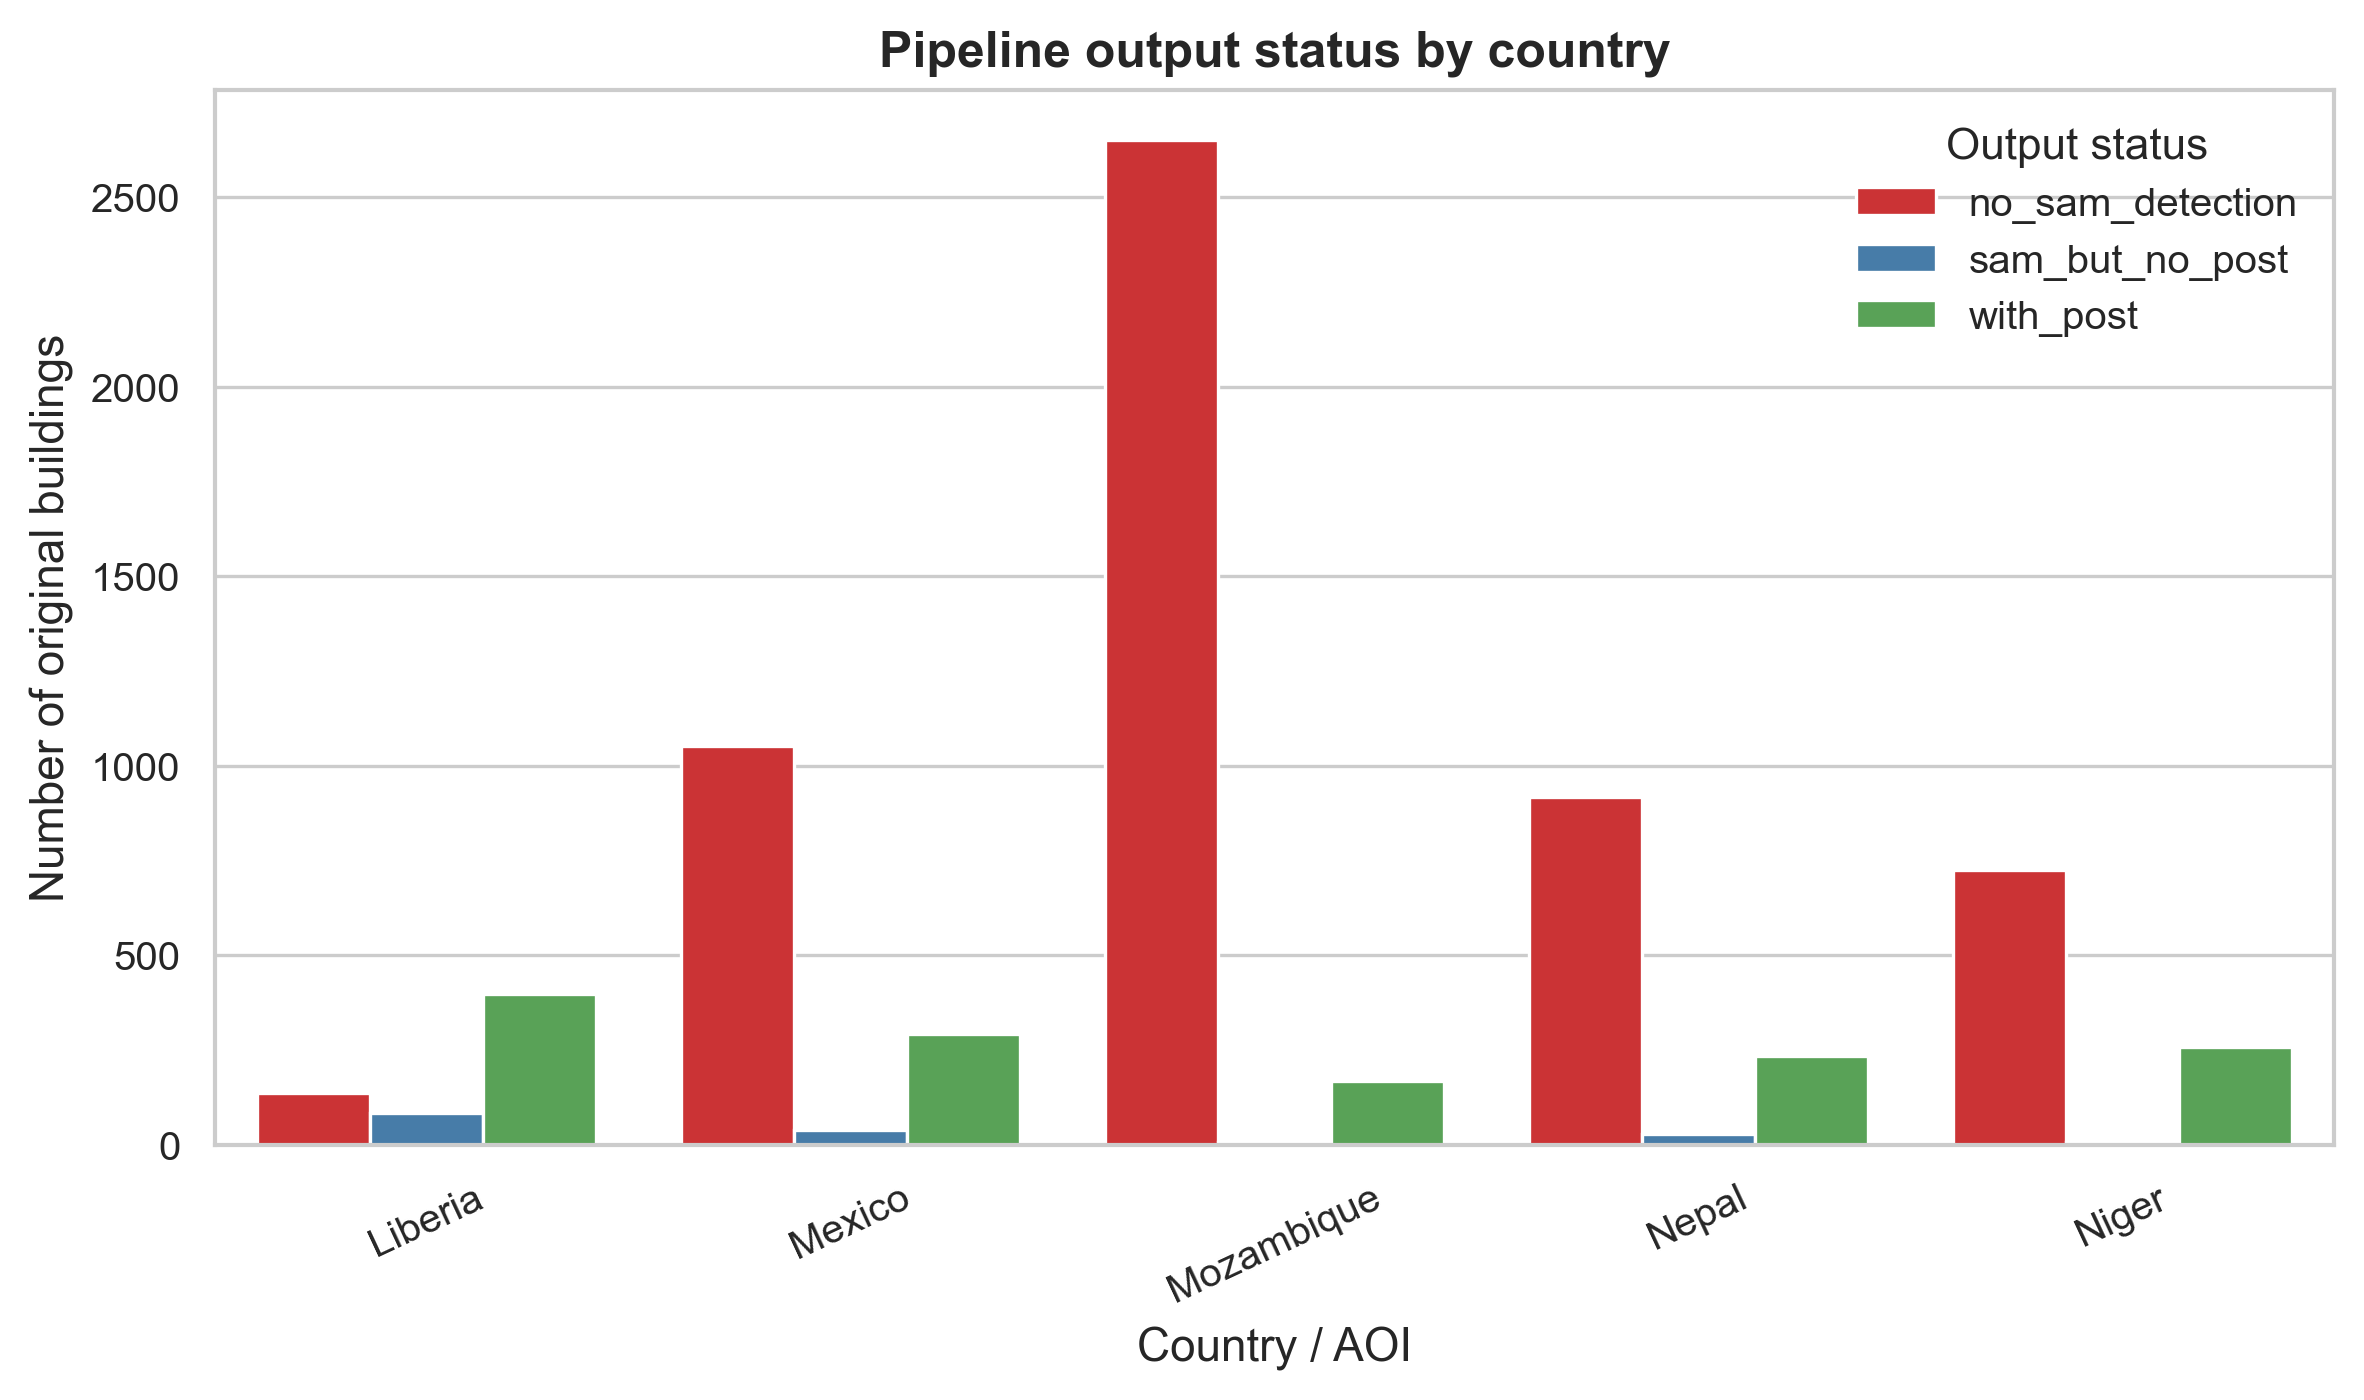

In [2]:
show_table("01_country_pipeline_coverage")
show_table("05_missing_outputs_by_country")
show_table("05_mlqa_error_counts")
show_table("05_semantic_error_category_frequency_compare")
show_table("05_semantic_error_category_agreement")
show_table("05_semantic_error_case_set_agreement")
show_figure("05_mlqa_presence_classes_by_country")
show_figure("05_output_status_by_country")
